In [ ]:
# ===================================================================================================
# LECTURE 27: van der Waals Residual Properties Calculator
# Author: Edward Maginn, CBE 20260
# Description: 
#   This notebook solves the cubic van der Waals equation of state for a variety of 
#   industrial gases, calculates the molar volume roots, and computes the residual 
#   thermodynamic properties (V^R, U^R, H^R, S^R) for the real physical roots.
# ===================================================================================================

# Install CoolProp if it is missing (e.g., on Google Colab)
try:
    import CoolProp
except ImportError:
    %pip install -q CoolProp

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import CoolProp.CoolProp as CP

# Dictionary mapping friendly names to CoolProp string identifiers
fluid_dict = {
    'Methane': 'Methane',
    'Nitrogen': 'Nitrogen',
    'Oxygen': 'Oxygen',
    'Ethane': 'Ethane',
    'Ammonia': 'Ammonia',
    'Carbon Dioxide': 'CarbonDioxide',
    'Carbon Monoxide': 'CarbonMonoxide',
    'Argon': 'Argon',
    'Water': 'Water',
    'R-32': 'R32'
}

def compute_residuals_and_plot(fluid_name, T_val, T_unit, P_val, P_unit):
    fluid = fluid_dict[fluid_name]
    
    # --- 1. Unit Conversions to Standard Math Units (Kelvin & bar) ---
    if T_unit == '°C': 
        T = T_val + 273.15
    elif T_unit == '°F': 
        T = (T_val - 32) * 5/9 + 273.15
    else: 
        T = T_val
        
    if P_unit == 'atm': 
        P = P_val * 1.01325
    elif P_unit == 'Pa': 
        P = P_val / 1e5
    elif P_unit == 'MPa': 
        P = P_val * 10
    elif P_unit == 'psi': 
        P = P_val / 14.5038
    else: 
        P = P_val

    if T <= 0 or P <= 0:
        print("Temperature and Pressure must be greater than absolute zero.")
        return

    # --- 2. Fetch Critical Properties ---
    Tc = CP.PropsSI('TCRIT', fluid)
    Pc_Pa = CP.PropsSI('PCRIT', fluid)
    Pc = Pc_Pa / 1e5  # Convert Pa to bar
    
    # --- 3. Calculate VDW Parameters ---
    R_Lbar = 0.0831446 # L*bar/(mol*K)
    R_J = 8.31446      # J/(mol*K)
    
    a = 27 * (R_Lbar * Tc)**2 / (64 * Pc)
    b = R_Lbar * Tc / (8 * Pc)
    
    # --- 4. Solve the Cubic Equation for Roots ---
    # V^3 - (b + RT/P)V^2 + (a/P)V - (ab/P) = 0
    C2 = -(b + R_Lbar * T / P)
    C1 = a / P
    C0 = -a * b / P
    
    roots = np.roots([1, C2, C1, C0])
    
    # Filter out complex roots and non-physical roots (V < b)
    real_roots = roots[np.isclose(roots.imag, 0)].real
    real_roots = np.sort(real_roots[real_roots > b])

    # --- 5. Print Output Summary & Residuals ---
    print("="*65)
    print(f"FLUID: {fluid_name}")
    print(f"Critical State: Tc = {Tc:.2f} K  |  Pc = {Pc:.2f} bar")
    print(f"VDW Parameters: a = {a:.4f} L^2·bar/mol^2  |  b = {b:.5f} L/mol")
    print("-" * 65)
    print(f"TARGET STATE:   T = {T:.2f} K  |  P = {P:.2f} bar")
    
    V_ideal = R_Lbar * T / P
    print(f"Ideal Gas Vol:  V_ig = {V_ideal:.4f} L/mol")
    print("="*65)
    
    for i, root in enumerate(real_roots):
        # Determine phase label
        if len(real_roots) == 1:
            phase = "Supercritical Fluid" if T > Tc else ("Liquid" if root < 5*b else "Vapor")
        elif len(real_roots) == 3:
            if i == 0: phase = "Liquid Root"
            elif i == 1: phase = "Unstable Root (Non-Physical)"
            else: phase = "Vapor Root"
            
        print(f"\n[{phase}]")
        print(f"  Molar Volume (V) = {root:.4f} L/mol")
        
        # Calculate Residuals for physical roots
        if phase != "Unstable Root (Non-Physical)":
            # 1. Residual Volume (L/mol)
            V_R = root - V_ideal
            
            # 2. Residual Internal Energy (J/mol)
            # U^R = -a/V (in L*bar/mol) -> multiply by 100 to get J/mol
            U_R = (-a / root) * 100 
            
            # 3. Residual Enthalpy (J/mol)
            # H^R = U^R + P(V - V_ideal) -> PV terms must be converted to J/mol
            H_R = U_R + 100 * P * V_R
            
            # 4. Residual Entropy (J/(mol K))
            # S^R = R * ln[ P(V-b) / RT ]
            arg = P * (root - b) / (R_Lbar * T)
            S_R = R_J * np.log(arg)
            
            print(f"  Residual Volume   (V^R) = {V_R:.4f} L/mol")
            print(f"  Residual Internal (U^R) = {U_R:.1f} J/mol")
            print(f"  Residual Enthalpy (H^R) = {H_R:.1f} J/mol")
            print(f"  Residual Entropy  (S^R) = {S_R:.3f} J/(mol·K)")
            
    print("\n" + "="*65)
    
    # --- 6. Plotting the P-V Diagram ---
    V_max = max(V_ideal * 1.5, 10 * b)
    if len(real_roots) == 3:
        V_max = max(V_max, real_roots[2] * 1.3)
        
    V_arr = np.linspace(b * 1.02, V_max, 2000)
    
    P_iso = (R_Lbar * T) / (V_arr - b) - a / (V_arr**2)
    P_crit = (R_Lbar * Tc) / (V_arr - b) - a / (V_arr**2)
    
    plt.figure(figsize=(9, 6))
    
    # Plot Isotherms
    plt.plot(V_arr, P_crit, 'r--', lw=1.5, label=f'Critical Isotherm (Tc = {Tc:.1f} K)')
    plt.plot(3*b, Pc, 'rs', markersize=6, label='Critical Point')
    plt.plot(V_arr, P_iso, 'b-', lw=2, label=f'Target Isotherm (T = {T:.1f} K)')
    plt.axhline(P, color='k', linestyle=':', lw=1.5, label=f'Target Pressure (P = {P:.1f} bar)')
    
    # Plot roots
    for i, root in enumerate(real_roots):
        if len(real_roots) == 3 and i == 1:
            plt.plot(root, P, 'wo', markeredgecolor='k', markersize=8, label='Unstable Root' if i==1 else "")
        else:
            plt.plot(root, P, 'go', markersize=8, label='Physical Root(s)' if i==0 else "")
            
    plt.ylim(0, max(P * 1.5, Pc * 1.5))
    plt.xlim(0, V_max)
    plt.xlabel('Molar Volume, V (L/mol)', fontsize=12)
    plt.ylabel('Pressure, P (bar)', fontsize=12)
    plt.title(f'van der Waals Properties for {fluid_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

# --- 7. Interactive UI Setup ---
style = {'description_width': 'initial'}

fluid_dropdown = widgets.Dropdown(options=list(fluid_dict.keys()), value='Methane', description='Fluid:')

T_input = widgets.FloatText(value=300, description='Temperature:', style=style, layout=widgets.Layout(width='200px'))
T_unit = widgets.Dropdown(options=['K', '°C', '°F'], value='K', layout=widgets.Layout(width='80px'))

P_input = widgets.FloatText(value=100, description='Pressure:', style=style, layout=widgets.Layout(width='200px'))
P_unit = widgets.Dropdown(options=['bar', 'atm', 'Pa', 'MPa', 'psi'], value='bar', layout=widgets.Layout(width='80px'))

T_box = widgets.HBox([T_input, T_unit])
P_box = widgets.HBox([P_input, P_unit])

ui = widgets.VBox([fluid_dropdown, T_box, P_box])
out = widgets.interactive_output(compute_residuals_and_plot, {
    'fluid_name': fluid_dropdown,
    'T_val': T_input,
    'T_unit': T_unit,
    'P_val': P_input,
    'P_unit': P_unit
})

display(ui, out)

Output()

FLUID: Methane
Critical State: Tc = 190.56 K  |  Pc = 45.99 bar
VDW Parameters: a = 2.3028 L^2·bar/mol^2  |  b = 0.04306 L/mol
-----------------------------------------------------------------
TARGET STATE:   T = 300.00 K  |  P = 100.00 bar
Ideal Gas Vol:  V_ig = 0.2494 L/mol

[Supercritical Fluid]
  Molar Volume (V) = 0.2032 L/mol
  Residual Volume   (V^R) = -0.0463 L/mol
  Residual Internal (U^R) = -1133.4 J/mol
  Residual Enthalpy (H^R) = -1595.9 J/mol
  Residual Entropy  (S^R) = -3.686 J/(mol·K)



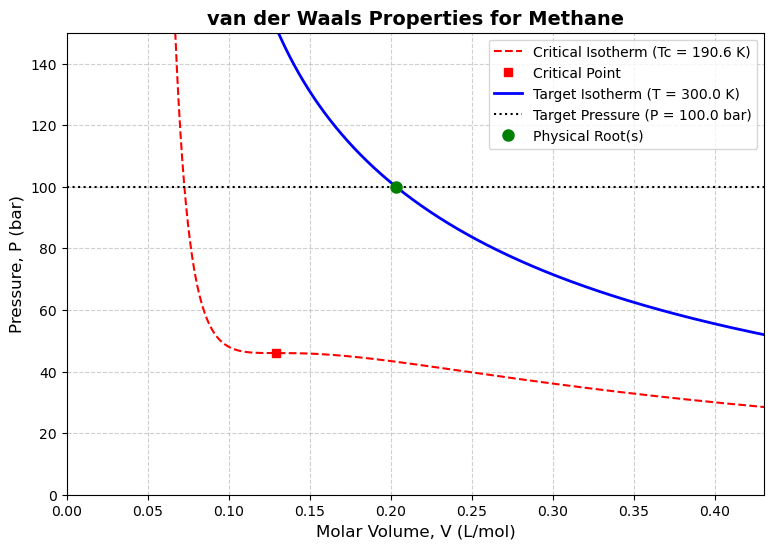

In [ ]:
# Static preview: results for the default inputs above.
# The output is saved so the course website can show it.
# To try other inputs, use the controls above, or open
# this notebook in Colab (badge on the course website).
compute_residuals_and_plot(fluid_name=fluid_dropdown.value, T_val=T_input.value, T_unit=T_unit.value,
                           P_val=P_input.value, P_unit=P_unit.value)